In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Define the folder containing the SQL analytical exports
data_path = r"C:\Users\john-\OneDrive\桌面\eleven\第二版\sql导出csv"
# Load monthly product performance data for product and time-series analysis
product_performance = pd.read_csv(
    os.path.join(data_path, "product_performance.csv"),
    header=None,
    names=[
        "year","quarter","month","month_name","month_number","month_period",
        "product_id","product_name","category","brand","revenue","orders",
        "units_sold","gross_profit","gross_margin_pct","month_start_date"
    ]
)
# Load product-level economic performance data for profitability analysis
product_economics = pd.read_csv(
    os.path.join(data_path, "product_economics.csv"),
    header=None,
    names=[
        "product_id","product_name","category","brand","units_sold","revenue",
        "total_cost","gross_profit","avg_selling_price","avg_unit_cost",
        "gross_margin_pct"
    ]
)
# Convert the monthly date field to pandas datetime format
product_performance["month_start_date"] = pd.to_datetime(
    product_performance["month_start_date"]
)
# Verify the imported datasets and their dimensions
print("product_performance:", product_performance.shape)
print("product_economics:", product_economics.shape)

# Check data types and missing values before product analysis
print("Product Performance NULLs:", product_performance.isna().sum().sum())
print("Product Economics NULLs:", product_economics.isna().sum().sum())
print("Unique Products:", product_economics["product_id"].nunique())
print("Unique Categories:", product_economics["category"].nunique())
print("Unique Brands:", product_economics["brand"].nunique())
print("Date Range:", product_performance["month_start_date"].min(), "to", product_performance["month_start_date"].max())

product_performance: (162804, 16)
product_economics: (2000, 11)
Product Performance NULLs: 0
Product Economics NULLs: 0
Unique Products: 2000
Unique Categories: 7
Unique Brands: 8
Date Range: 2019-01-01 00:00:00 to 2025-12-01 00:00:00


In [3]:
# Rank products by revenue, units sold, and gross profit to identify key products
product_ranking = product_economics.copy()
product_ranking["revenue_share_pct"] = (
    product_ranking["revenue"] /
    product_ranking["revenue"].sum() * 100
)
product_ranking["profit_share_pct"] = (
    product_ranking["gross_profit"] /
    product_ranking["gross_profit"].sum() * 100
)
product_ranking = product_ranking.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)
product_ranking["revenue_rank"] = product_ranking.index + 1
product_ranking.head(10)

,product_id,product_name,category,brand,units_sold,revenue,total_cost,gross_profit,avg_selling_price,avg_unit_cost,gross_margin_pct,revenue_share_pct,profit_share_pct,revenue_rank
0,83fbdf52-21a3-4b64-af45-76ff4437130b,Nimbus Headphones M767,electronics,Nimbus,2478,4938901.80,3817284.66,1121617.14,1993.10,1540.47,0.2271,0.502360,0.445975,1
1,9086b2b2-6100-410b-9b9c-4db4109afcfa,Apex P960 Smartwatch,electronics,Apex,2527,4894925.35,3741728.90,1153196.45,1937.05,1480.70,0.2356,0.497887,0.458532,2
2,d27b9b19-b9a9-4ea7-8f5a-253a977fdc4d,Nova Monitor A779,electronics,Nova,2489,4893846.91,3902279.09,991567.82,1966.19,1567.81,0.2026,0.497778,0.394265,3
3,7943b8ca-e76d-41b5-a01d-69e33614b774,Orion P631 Tablet,electronics,Orion,2460,4877712.60,3703972.80,1173739.80,1982.81,1505.68,0.2406,0.496137,0.466700,4
4,0be8ed49-fc0e-4841-b19f-a668ade1a1aa,Apex Headphones S938,electronics,Apex,2483,4836486.72,3782180.09,1054306.63,1947.84,1523.23,0.2180,0.491943,0.419212,5
5,cbceed2a-2fef-4be6-9b8b-e6e3b03a6863,Nova M311 Tablet,electronics,Nova,2454,4823852.34,3948216.06,875636.28,1965.71,1608.89,0.1815,0.490658,0.348169,6
6,3952c856-34d0-435b-9ebc-4e05532cb5ac,Pulse X774 Smartwatch,electronics,Pulse,2497,4823155.26,4154833.21,668322.05,1931.58,1663.93,0.1386,0.490587,0.265737,7
7,0726d086-56b4-4a93-8696-87ceee82dc51,Apex Tablet X807,electronics,Apex,2381,4761642.85,3717169.58,1044473.27,1999.85,1561.18,0.2194,0.484331,0.415302,8
8,8a1b95bf-694e-44af-9ae4-af574fdcf0eb,Nova P896 Camera,electronics,Nova,2457,4760142.66,3749357.43,1010785.23,1937.38,1525.99,0.2123,0.484178,0.401907,9
9,b19d2bb6-43a7-4ef8-9273-855ef5acf0dc,Nimbus A208 Camera,electronics,Nimbus,2514,4758172.38,4197223.56,560948.82,1892.67,1669.54,0.1179,0.483978,0.223043,10


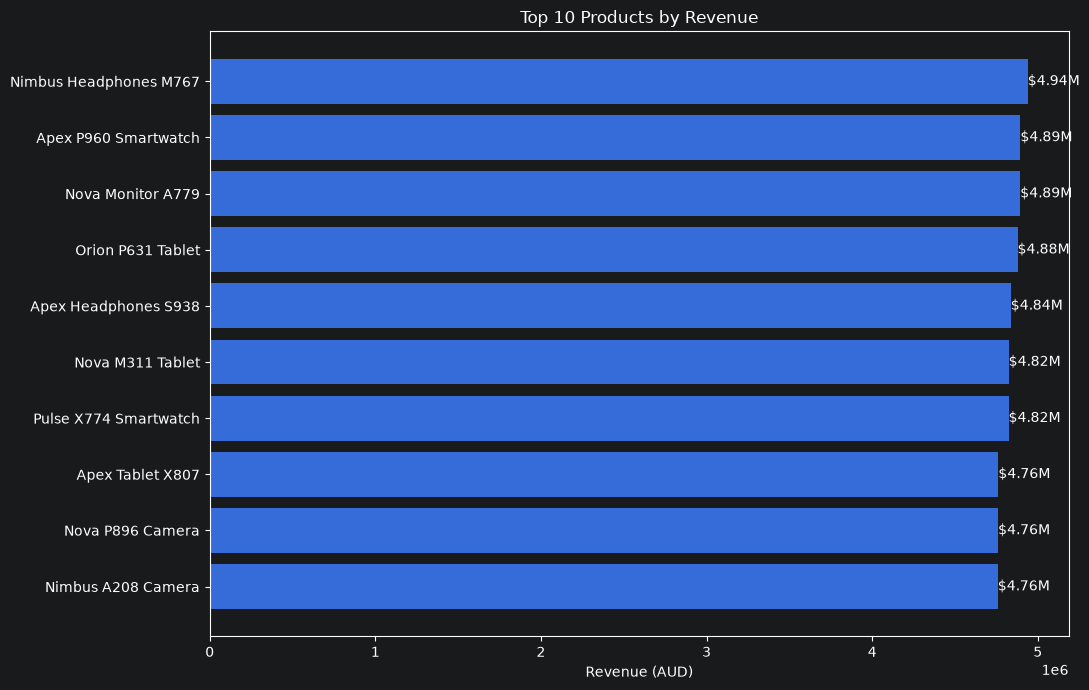

In [4]:
# Select the top 10 products by revenue for portfolio visualization
top10_products = product_ranking.head(10).sort_values("revenue")
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top10_products["product_name"],
    top10_products["revenue"]
)
# Add revenue labels to each product bar
for bar, value in zip(bars, top10_products["revenue"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value / 1_000_000:.2f}M",
        va="center",
        ha="left"
    )
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (AUD)")
plt.tight_layout()
plt.show()

In [5]:
# Calculate cumulative revenue contribution across ranked products
product_concentration = product_ranking[
    ["product_id", "product_name", "revenue"]
].copy()
total_revenue = product_concentration["revenue"].sum()
product_concentration["revenue_share_pct"] = (
    product_concentration["revenue"] / total_revenue * 100
)
product_concentration["cumulative_revenue_pct"] = (
    product_concentration["revenue_share_pct"].cumsum()
)
product_concentration["product_rank"] = np.arange(
    1,
    len(product_concentration) + 1
)
# Calculate revenue contribution from key product groups
concentration_summary = []
for pct in [1, 5, 10, 20, 50]:
    n = int(len(product_concentration) * pct / 100)
    revenue_share = (
        product_concentration.iloc[:n]["revenue"].sum()
        / total_revenue * 100
    )
    concentration_summary.append({
        "product_group": f"Top {pct}%",
        "products": n,
        "revenue_share_pct": revenue_share
    })
concentration_summary = pd.DataFrame(concentration_summary)
concentration_summary

,product_group,products,revenue_share_pct
0,Top 1%,20,9.612057
1,Top 5%,100,40.448577
2,Top 10%,200,66.656567
3,Top 20%,400,80.925009
4,Top 50%,1000,95.370949


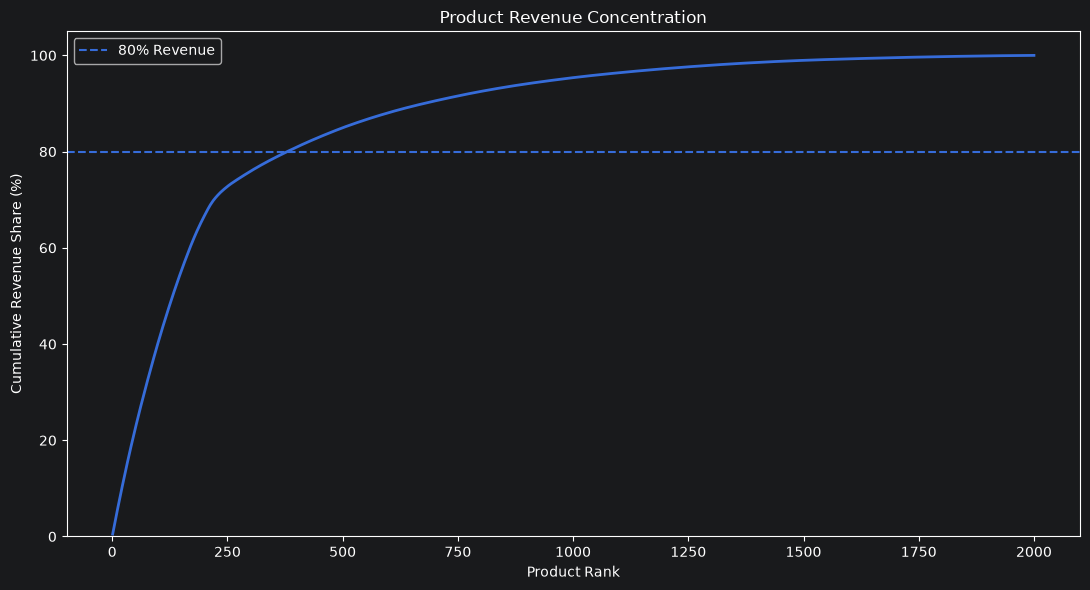

In [6]:
# Visualize cumulative revenue concentration across products
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    product_concentration["product_rank"],
    product_concentration["cumulative_revenue_pct"],
    linewidth=2
)
ax.axhline(80, linestyle="--", label="80% Revenue")
ax.set_title("Product Revenue Concentration")
ax.set_xlabel("Product Rank")
ax.set_ylabel("Cumulative Revenue Share (%)")
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

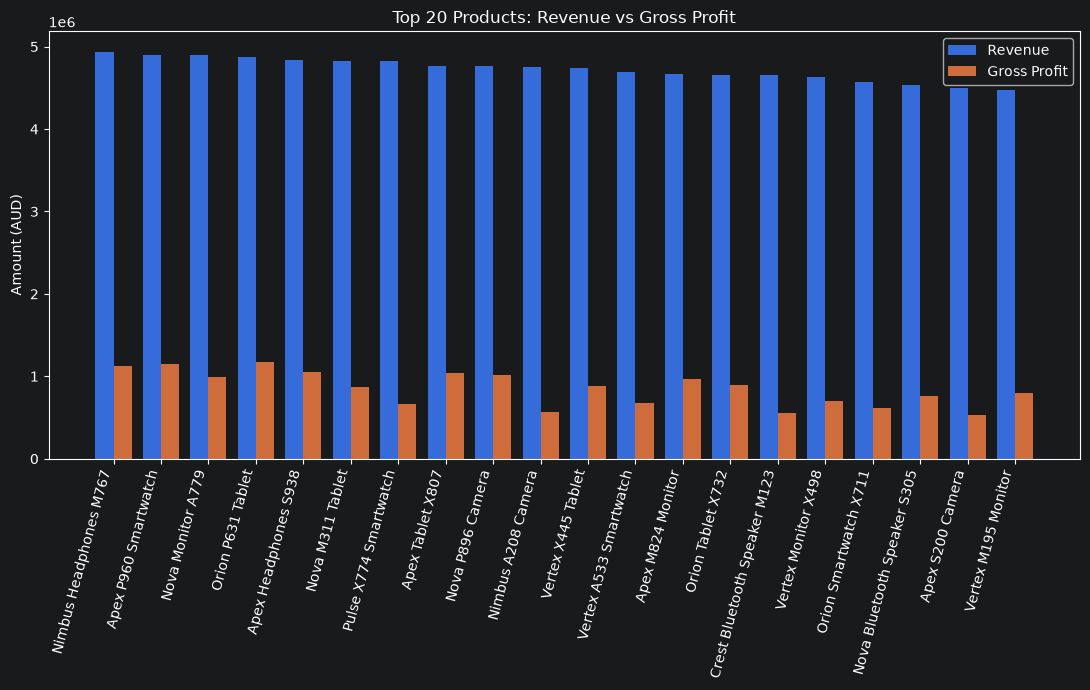

In [7]:
# Compare product revenue with gross profit to identify high-value and high-profit products
profit_chart = product_ranking.sort_values(
    "revenue",
    ascending=False
).head(20)
fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(profit_chart))
width = 0.38
ax.bar(
    x - width / 2,
    profit_chart["revenue"],
    width,
    label="Revenue"
)
ax.bar(
    x + width / 2,
    profit_chart["gross_profit"],
    width,
    label="Gross Profit"
)
ax.set_title("Top 20 Products: Revenue vs Gross Profit")
ax.set_ylabel("Amount (AUD)")
ax.set_xticks(x)
ax.set_xticklabels(
    profit_chart["product_name"],
    rotation=75,
    ha="right"
)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Identify products with strong revenue and gross margin performance
margin_analysis = product_ranking[
    [
        "product_id",
        "product_name",
        "category",
        "revenue",
        "gross_profit",
        "gross_margin_pct"
    ]
].copy()
# Identify high-revenue products using the top 10% revenue threshold
revenue_threshold = margin_analysis["revenue"].quantile(0.90)
margin_analysis["high_revenue_flag"] = (
    margin_analysis["revenue"] >= revenue_threshold
)
# Rank products by gross margin to identify highly profitable products
high_margin_products = margin_analysis.sort_values(
    "gross_margin_pct",
    ascending=False
).head(20)
high_margin_products

,product_id,product_name,category,revenue,gross_profit,gross_margin_pct,high_revenue_flag
923,c1157432-7484-419e-a6c7-1b40d84dde53,Nova Classic Jacket,fashion,130802.26,95205.44,0.7279,False
1229,f130ae8f-e404-4a94-aa43-d60f10fb4824,Zenith Backpack (Blue),fashion,72785.77,52902.67,0.7268,False
673,e39b6500-02c2-40b8-abf2-16db5fc1c5fd,Zenith Dress (White),fashion,223212.78,162129.21,0.7263,False
434,224d3e84-0c5b-4156-a45f-d6691af447df,Pulse Backpack (Green),fashion,407920.63,296150.94,0.7260,False
592,d0d6ea2f-915e-4c9c-bc35-019c9ec78cea,Pulse Classic Jacket,fashion,278036.60,201635.55,0.7252,False
472,6efd591c-6de5-443a-ba5b-d75e9581057e,Nimbus Classic Hoodie,fashion,377496.01,273767.39,0.7252,False
861,1d1c96ae-37b2-4e72-8389-7bc499b9e940,Orion Backpack (Black),fashion,151214.31,109614.45,0.7249,False
388,3f5dc73f-8031-4279-88bf-a9f506fb8852,Vertex Cozy Hoodie,fashion,448053.41,324741.13,0.7248,False
666,fa6e102c-4eda-4fbb-93eb-d081fb261a65,Crest Hoodie (White),fashion,225132.23,163182.23,0.7248,False
1375,2887466c-0d26-44ce-9acf-1b9f11309791,Zenith Cozy Backpack,fashion,51455.28,37264.60,0.7242,False


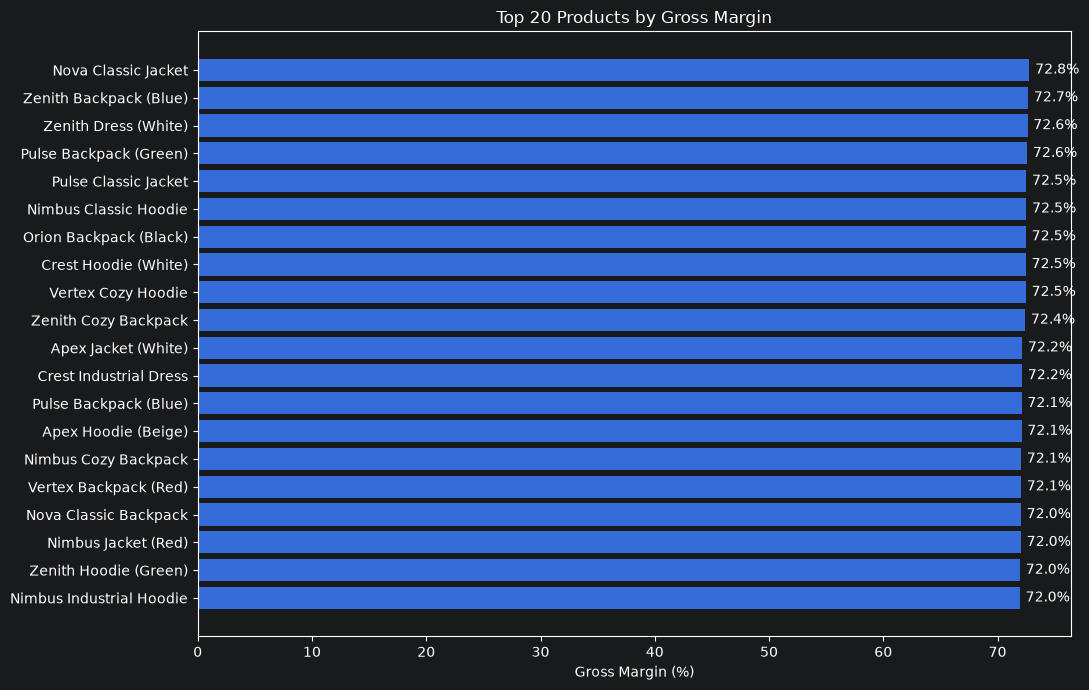

In [9]:
# Visualize the top 20 products by gross margin
margin_chart = high_margin_products.sort_values("gross_margin_pct")
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    margin_chart["product_name"],
    margin_chart["gross_margin_pct"] * 100
)
# Add gross margin labels to each product
for bar, value in zip(
    bars,
    margin_chart["gross_margin_pct"] * 100
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )
ax.set_title("Top 20 Products by Gross Margin")
ax.set_xlabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [10]:
# Aggregate product economics by category to compare revenue and profitability
category_product_analysis = product_economics.groupby(
    "category",
    as_index=False
).agg(
    products=("product_id", "nunique"),
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_selling_price=("avg_selling_price", "mean")
)
# Calculate gross margin and revenue share for each category
category_product_analysis["gross_margin_pct"] = (
    category_product_analysis["gross_profit"]
    / category_product_analysis["revenue"]
)
category_product_analysis["revenue_share_pct"] = (
    category_product_analysis["revenue"]
    / category_product_analysis["revenue"].sum() * 100
)
category_product_analysis = category_product_analysis.sort_values(
    "revenue",
    ascending=False
)
category_product_analysis

,category,products,units_sold,revenue,gross_profit,avg_selling_price,gross_margin_pct,revenue_share_pct
2,electronics,286,690041,7.327754e+08,1.333925e+08,1060.698147,0.182037,74.534252
4,furniture,309,196837,1.090914e+08,4.435314e+07,554.420841,0.406569,11.096231
3,fashion,275,474092,6.782140e+07,4.236778e+07,143.110145,0.624696,6.898454
5,home_goods,281,315249,3.388317e+07,1.668173e+07,107.706833,0.492331,3.446427
0,auto,280,78697,2.122451e+07,5.449374e+06,269.189357,0.256749,2.158851
6,toys,259,248963,1.258810e+07,6.959558e+06,50.576718,0.552868,1.280399
1,books,310,195940,5.755156e+06,2.293448e+06,29.391000,0.398503,0.585386


In [11]:
# Aggregate product revenue and units sold by month for trend analysis
product_trend = product_performance.groupby(
    ["month_start_date", "year", "month"],
    as_index=False
).agg(
    revenue=("revenue", "sum"),
    units_sold=("units_sold", "sum"),
    products=("product_id", "nunique")
)
product_trend["revenue_mom_pct"] = (
    product_trend["revenue"].pct_change() * 100
)
product_trend = product_trend.sort_values(
    "month_start_date"
).reset_index(drop=True)
product_trend.tail()

,month_start_date,year,month,revenue,units_sold,products,revenue_mom_pct
79,2025-08-01,2025,8,19656108.56,61159,1999,6.803615
80,2025-09-01,2025,9,13755817.30,35048,1998,-30.017596
81,2025-10-01,2025,10,13950091.11,35611,2000,1.412303
82,2025-11-01,2025,11,63939806.14,99741,2000,358.346871
83,2025-12-01,2025,12,60690851.53,93894,2000,-5.081271


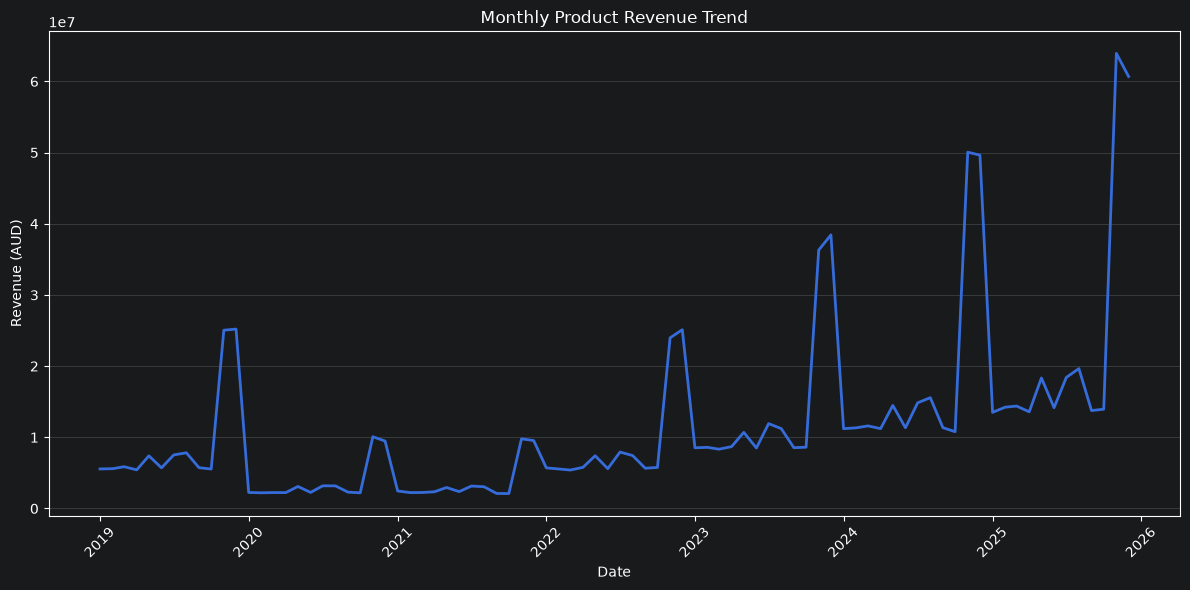

In [12]:
# Visualize monthly product revenue over the full analysis period
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    product_trend["month_start_date"],
    product_trend["revenue"],
    linewidth=2
)
ax.set_title("Monthly Product Revenue Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (AUD)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

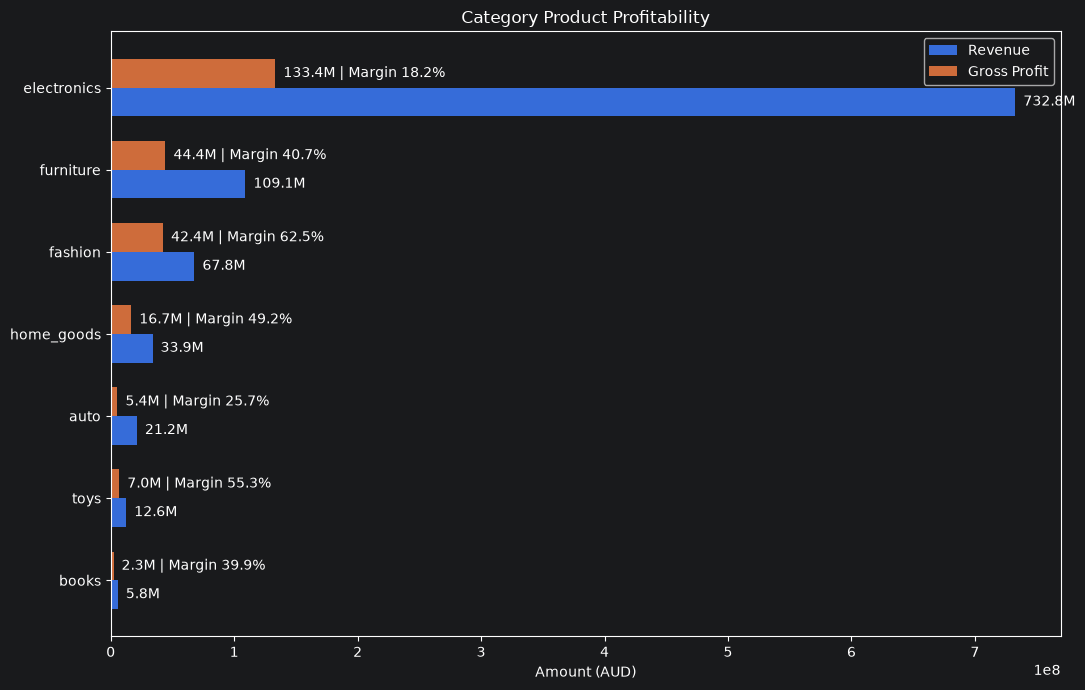

In [13]:
# Prepare category-level profitability data for portfolio visualization
category_profit_chart = category_product_analysis.sort_values(
    "revenue",
    ascending=True
).copy()
# Create a grouped horizontal bar chart comparing revenue and gross profit
fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(category_profit_chart))
height = 0.35
ax.barh(
    y - height / 2,
    category_profit_chart["revenue"],
    height,
    label="Revenue"
)
ax.barh(
    y + height / 2,
    category_profit_chart["gross_profit"],
    height,
    label="Gross Profit"
)
# Add gross margin labels to show profitability differences between categories
for i, row in category_profit_chart.reset_index(drop=True).iterrows():
    ax.text(
        row["revenue"],
        i - height / 2,
        f"  {row['revenue'] / 1_000_000:.1f}M",
        va="center"
    )
    ax.text(
        row["gross_profit"],
        i + height / 2,
        f"  {row['gross_profit'] / 1_000_000:.1f}M | Margin {row['gross_margin_pct'] * 100:.1f}%",
        va="center"
    )
ax.set_title("Category Product Profitability")
ax.set_xlabel("Amount (AUD)")
ax.set_yticks(y)
ax.set_yticklabels(category_profit_chart["category"])
ax.legend()
plt.tight_layout()
plt.show()

Key Product Insights

## Product Revenue Concentration
Product revenue is highly concentrated among the top-performing products. The top 10% of products generate 66.66% of total revenue, while the top 20% generate 80.93%. This indicates that a relatively small portion of the product portfolio drives a large share of sales.

## Top Revenue Products
The top 10 products are all from the Electronics category. However, each individual product contributes approximately 0.5% of total revenue, indicating that revenue is concentrated at the category level rather than being dominated by a single product.

## Revenue vs Gross Profit
High revenue does not necessarily translate into the highest profitability. Electronics generates the majority of product revenue, but its gross margin is approximately 18.20%, substantially lower than several other categories.

## Product Margin
Several Fashion products achieve gross margins above 70%, demonstrating strong unit-level profitability. However, gross margin percentage should be considered together with revenue and gross profit because a high-margin product may generate less absolute profit than a high-volume product.

## Category Profitability
Electronics contributes 74.53% of revenue and 53.04% of gross profit, making it the core revenue category. Fashion contributes only 6.90% of revenue but 16.85% of gross profit, reflecting its significantly higher gross margin.

## Product Revenue Trend
Monthly product revenue shows substantial variation over time, with a particularly strong increase in November 2025. The number of active products also increased during this period, indicating broad product participation in the revenue increase.